# 08 - Dynamic Communities 

In [1]:
# ── Repository root ───────────────────────────────────────────────────────────
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks', 'legacy') else Path.cwd()
assert (ROOT / 'data').is_dir(), f'Repository root not found from {Path.cwd()}'

## 0 - Params

In [2]:
SEASONAL_CSV = ROOT / 'data' / 'networks' / 'community_assignments_seasonal_v2.csv.gz'
NETWORKS_DIR = ROOT / 'data' / 'networks'
FIGURES_DIR  = ROOT / 'figures'
OUT_JSON     = ROOT / 'data' / 'analysis' / 'dynamic_results_v2.json'

THETA_J = 0.15

TAU_ASYM = 0.50

MIN_COMM_SIZE         = 5      
SIZE_CHANGE_THRESHOLD = 0.50   # +/-50% -> growth / shrink

SEASONS = ['winter_0', 'spring', 'summer', 'autumn', 'winter_1']
SEASON_NAMES = {'winter_0': 'Winter_0', 'spring': 'Spring', 'summer': 'Summer',
                'autumn': 'Autumn', 'winter_1': 'Winter_1'}
LATEX_SEASON = {'winter_0': r'Winter$_0$', 'spring': 'Spring', 'summer': 'Summer',
                'autumn': 'Autumn', 'winter_1': r'Winter$_1$'}

ALGOS = ['louvain', 'infomap']

SEASON_PAL = {'winter_0': '#5B8EB8', 'spring': '#7FB069', 'summer': '#E0A040',
              'autumn': '#C7563C', 'winter_1': '#3A6B99'}
ICONIC_PAL = {
    'Insecta': '#4C9B7A', 'Aves': '#5B8EB8', 'Reptilia': '#C7A540',
    'Amphibia': '#7B61A8', 'Mammalia': '#C7563C', 'Arachnida': '#8B4513',
    'Actinopterygii': '#20B2AA', 'Mollusca': '#FF8C69', 'Other': '#AAAAAA',
}
EVENT_TYPES = ['continuation', 'growth', 'shrink', 'merge', 'split', 'birth', 'death']
EVENT_COLORS = {
    'continuation': '#4C9B7A', 'growth': '#7FB069', 'shrink': '#C7A540',
    'merge': '#5B8EB8', 'split': '#E0A040', 'birth': '#7B61A8', 'death': '#C7563C',
}

import os
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(ROOT / 'data' / 'analysis', exist_ok=True)
print('Parameters set.')

Parameters set.


In [3]:
import json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import seaborn as sns
from collections import defaultdict, Counter

sns.set_theme(style='ticks', context='paper', font_scale=1.1, rc={
    'font.family': 'serif', 'axes.linewidth': 0.7,
})

def savefig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(f'{FIGURES_DIR}/{name}.{ext}', dpi=300,
                    bbox_inches='tight', pad_inches=0.05)
    print(f'  saved {FIGURES_DIR}/{name}.png + .pdf')

df = pd.read_csv(SEASONAL_CSV)
print(f'Caricati {len(df):,} nodi backbone')
print(f'Colonne: {list(df.columns)}')

taxon_iconic = dict(zip(df['taxon_id'], df['iconic_taxon']))
taxon_name   = dict(zip(df['taxon_id'], df['species_name']))

Caricati 3,009 nodi backbone
Colonne: ['taxon_id', 'species_name', 'iconic_taxon', 'annual_louvain', 'annual_infomap', 'winter_0_louvain', 'winter_0_infomap', 'spring_louvain', 'spring_infomap', 'summer_louvain', 'summer_infomap', 'autumn_louvain', 'autumn_infomap', 'winter_1_louvain', 'winter_1_infomap']


In [4]:
def load_communities(df, algo, min_size=MIN_COMM_SIZE):
    """{stagione: {community_id: set(taxon_id)}} per un dato algoritmo."""
    out = {}
    for s in SEASONS:
        col = f'{s}_{algo}'
        comms = defaultdict(set)
        for tid, cid in zip(df['taxon_id'], df[col]):
            if cid >= 0:
                comms[int(cid)].add(int(tid))
        out[s] = {c: m for c, m in comms.items() if len(m) >= min_size}
    return out


season_comms = {algo: load_communities(df, algo) for algo in ALGOS}

print(f'Comunita con almeno {MIN_COMM_SIZE} nodi:')
print(f'{"Season":<12}' + ''.join(f'{a:>12}' for a in ALGOS))
print('-' * 36)
for s in SEASONS:
    print(f'{SEASON_NAMES[s]:<12}' + ''.join(f'{len(season_comms[a][s]):>12d}' for a in ALGOS))

Comunita con almeno 5 nodi:
Season           louvain     infomap
------------------------------------
Winter_0              32           9
Spring                41           8
Summer                27           7
Autumn                12           9
Winter_1              22           5


In [5]:
def jaccard(a, b):
    u = len(a | b)
    return len(a & b) / u if u else 0.0


def overlaps(a, b):
    """(forward, backward): frazione di `a` che sopravvive, frazione di `b` che eredita."""
    inter = len(a & b)
    return (inter / len(a) if a else 0.0,
            inter / len(b) if b else 0.0)


def match_symmetric(c_t, c_t1, theta=THETA_J):
    out = []
    for ci, mi in c_t.items():
        for cj, mj in c_t1.items():
            j = jaccard(mi, mj)
            if j >= theta:
                out.append((ci, cj, round(j, 4)))
    return out


def match_asymmetric(c_t, c_t1, tau=TAU_ASYM):
    out = []
    for ci, mi in c_t.items():
        for cj, mj in c_t1.items():
            f, b = overlaps(mi, mj)
            if f >= tau or b >= tau:
                out.append((ci, cj, round(max(f, b), 4)))
    return out


MATCHERS = {'jaccard': match_symmetric, 'asymmetric': match_asymmetric}
print('Matcher definiti:', list(MATCHERS))

Matcher definiti: ['jaccard', 'asymmetric']


## 2 - events

In [6]:
def classify_events(c_t, c_t1, matches):
    """Classifica gli eventi di una transizione a partire dai match trovati.

    Regole:
      - nessun match in uscita            -> death
      - >= 2 match in uscita              -> split
      - 1 match in uscita, 1 in entrata   -> continuation / growth / shrink
      - >= 2 match in entrata sul target  -> merge
      - nessun match in entrata           -> birth
    """
    out_deg, in_deg = defaultdict(list), defaultdict(list)
    for ci, cj, _ in matches:
        out_deg[ci].append(cj)
        in_deg[cj].append(ci)

    events = []
    for ci in c_t:
        targets = out_deg.get(ci, [])
        if not targets:
            events.append({'type': 'death', 'from': [ci], 'to': [],
                           'size_from': len(c_t[ci]), 'size_to': 0})
        elif len(targets) >= 2:
            events.append({'type': 'split', 'from': [ci], 'to': targets,
                           'size_from': len(c_t[ci]),
                           'size_to': sum(len(c_t1[t]) for t in targets)})
        else:
            cj = targets[0]
            if len(in_deg.get(cj, [])) == 1:
                sf, st = len(c_t[ci]), len(c_t1[cj])
                delta = (st - sf) / sf if sf else 0.0
                if delta > SIZE_CHANGE_THRESHOLD:
                    et = 'growth'
                elif delta < -SIZE_CHANGE_THRESHOLD:
                    et = 'shrink'
                else:
                    et = 'continuation'
                events.append({'type': et, 'from': [ci], 'to': [cj],
                               'size_from': sf, 'size_to': st,
                               'delta': round(delta, 3)})

    for cj, sources in in_deg.items():
        if len(sources) >= 2:
            events.append({'type': 'merge', 'from': sources, 'to': [cj],
                           'size_from': sum(len(c_t[s]) for s in sources),
                           'size_to': len(c_t1[cj])})

    for cj in c_t1:
        if not in_deg.get(cj, []):
            events.append({'type': 'birth', 'from': [], 'to': [cj],
                           'size_from': 0, 'size_to': len(c_t1[cj])})

    return events


TRANSITIONS = list(zip(SEASONS[:-1], SEASONS[1:]))
print('Transizioni:', [f'{SEASON_NAMES[a]}->{SEASON_NAMES[b]}' for a, b in TRANSITIONS])

Transizioni: ['Winter_0->Spring', 'Spring->Summer', 'Summer->Autumn', 'Autumn->Winter_1']


In [8]:
all_events = {}
event_counts = {}

for algo in ALGOS:
    for mname, mfun in MATCHERS.items():
        key = (algo, mname)
        all_events[key] = {}
        event_counts[key] = {}
        for s1, s2 in TRANSITIONS:
            m = mfun(season_comms[algo][s1], season_comms[algo][s2])
            ev = classify_events(season_comms[algo][s1], season_comms[algo][s2], m)
            all_events[key][(s1, s2)] = ev
            event_counts[key][(s1, s2)] = Counter(e['type'] for e in ev)

for algo in ALGOS:
    for mname in MATCHERS:
        key = (algo, mname)
        print(f'=== {algo.upper()} partitions, {mname} matching ===')
        print(f'{"Transition":<26}' + ''.join(f'{t[:6]:>8}' for t in EVENT_TYPES))
        print('-' * (26 + 8*len(EVENT_TYPES)))
        tot = Counter()
        for s1, s2 in TRANSITIONS:
            c = event_counts[key][(s1, s2)]
            tot.update(c)
            label = f'{SEASON_NAMES[s1]}->{SEASON_NAMES[s2]}'
            print(f'{label:<26}' + ''.join(f'{c.get(t, 0):>8d}' for t in EVENT_TYPES))
        print(f'{"TOTAL":<26}' + ''.join(f'{tot.get(t, 0):>8d}' for t in EVENT_TYPES))
        persist = sum(tot.get(t, 0) for t in
                      ['continuation', 'growth', 'shrink', 'merge', 'split'])
        turnover = tot.get('birth', 0) + tot.get('death', 0)
        print(f'  persistenza={persist}  turnover={turnover}  '
              f'totale={persist+turnover}  turnover%={100*turnover/(persist+turnover):.1f}%')
        print()

=== LOUVAIN partitions, jaccard matching ===
Transition                  contin  growth  shrink   merge   split   birth   death
----------------------------------------------------------------------------------
Winter_0->Spring                 1       1       1       1       1      36      27
Spring->Summer                   3       2       0       0       0      22      36
Summer->Autumn                   4       0       0       1       0       7      21
Autumn->Winter_1                 0       0       2       0       0      20      10
TOTAL                            8       3       3       2       1      85      94
  persistenza=17  turnover=179  totale=196  turnover%=91.3%

=== LOUVAIN partitions, asymmetric matching ===
Transition                  contin  growth  shrink   merge   split   birth   death
----------------------------------------------------------------------------------
Winter_0->Spring                 0       2       1       2       0      36      23
Spring->Summer  

In [9]:
#  birth - death
print('Bilancio netto (birth - death) per transizione:')
print(f'{"Transition":<26}' + ''.join(f'{a[:3]}/{m[:4]:<8}'
                                      for a in ALGOS for m in MATCHERS))
print('-' * 70)
net_balance = {}
for s1, s2 in TRANSITIONS:
    label = f'{SEASON_NAMES[s1]}->{SEASON_NAMES[s2]}'
    vals = []
    for algo in ALGOS:
        for mname in MATCHERS:
            c = event_counts[(algo, mname)][(s1, s2)]
            vals.append(c.get('birth', 0) - c.get('death', 0))
    net_balance[(s1, s2)] = vals
    print(f'{label:<26}' + ''.join(f'{v:>+12d}' for v in vals))
print()


Bilancio netto (birth - death) per transizione:
Transition                lou/jacc    lou/asym    inf/jacc    inf/asym    
----------------------------------------------------------------------
Winter_0->Spring                    +9         +13          -1          +1
Spring->Summer                     -14         -11          -1          -1
Summer->Autumn                     -14         -13          +2          +2
Autumn->Winter_1                   +10         +10          -4          -5



## 4 - edge overlap between seasonal layers

In [10]:
edge_sets = {}
for s in SEASONS:
    path = NETWORKS_DIR / f'{s}_layer.graphml.gz'
    if not os.path.exists(path):
        print(f'  ATTENZIONE: {path} non trovato')
        continue
    L = nx.read_graphml(path)
    edge_sets[s] = {frozenset((u, v)) for u, v in L.edges()}
    print(f'  {SEASON_NAMES[s]:<10}: {len(edge_sets[s]):>8,} archi')

seas = [s for s in SEASONS if s in edge_sets]
n_s = len(seas)
edge_jac = np.zeros((n_s, n_s))
for i, a in enumerate(seas):
    for j, b in enumerate(seas):
        u = edge_sets[a] | edge_sets[b]
        edge_jac[i, j] = len(edge_sets[a] & edge_sets[b]) / len(u) if u else 0.0

df_edge_jac = pd.DataFrame(edge_jac, index=[SEASON_NAMES[s] for s in seas],
                           columns=[SEASON_NAMES[s] for s in seas])
print()
print('Edge Jaccard fra layer stagionali:')
print(df_edge_jac.round(3).to_string())
print()

off = edge_jac.copy()
np.fill_diagonal(off, np.nan)
i, j = np.unravel_index(np.nanargmax(off), off.shape)
print(f'Massimo fuori diagonale: {off[i,j]:.3f} '
      f'({df_edge_jac.index[i]} vs {df_edge_jac.columns[j]})')

adj = [(seas[k], seas[k+1], edge_jac[k, k+1]) for k in range(n_s - 1)]
print('Coppie adiacenti:')
for a, b, v in adj:
    print(f'  {SEASON_NAMES[a]:<10} - {SEASON_NAMES[b]:<10} {v:.3f}')
print(f'Massimo fra adiacenti: {max(v for _, _, v in adj):.3f}')
w0w1 = edge_jac[seas.index('winter_0'), seas.index('winter_1')]
print(f'Winter_0 - Winter_1 : {w0w1:.3f}  '
      f'({w0w1/max(v for _, _, v in adj):.1f}x il massimo fra adiacenti)')

  Winter_0  :   40,757 archi
  Spring    :  144,444 archi
  Summer    :  178,998 archi
  Autumn    :  223,590 archi
  Winter_1  :   43,119 archi

Edge Jaccard fra layer stagionali:
          Winter_0  Spring  Summer  Autumn  Winter_1
Winter_0     1.000   0.126   0.059   0.124     0.430
Spring       0.126   1.000   0.201   0.191     0.131
Summer       0.059   0.201   1.000   0.205     0.060
Autumn       0.124   0.191   0.205   1.000     0.132
Winter_1     0.430   0.131   0.060   0.132     1.000

Massimo fuori diagonale: 0.430 (Winter_0 vs Winter_1)
Coppie adiacenti:
  Winter_0   - Spring     0.126
  Spring     - Summer     0.201
  Summer     - Autumn     0.205
  Autumn     - Winter_1   0.132
Massimo fra adiacenti: 0.205
Winter_0 - Winter_1 : 0.430  (2.1x il massimo fra adiacenti)


## 5 - Winter_0 vs Winter_1

In [11]:
winter_results = {}

for algo in ALGOS:
    W0 = season_comms[algo]['winter_0']
    W1 = season_comms[algo]['winter_1']
    w0_ids, w1_ids = sorted(W0), sorted(W1)

    jm = np.zeros((len(w0_ids), len(w1_ids)))
    fm = np.zeros_like(jm)
    bm = np.zeros_like(jm)
    for i, c0 in enumerate(w0_ids):
        for j, c1 in enumerate(w1_ids):
            jm[i, j] = jaccard(W0[c0], W1[c1])
            fm[i, j], bm[i, j] = overlaps(W0[c0], W1[c1])

    best_j = jm.max(axis=1) if len(w1_ids) else np.zeros(len(w0_ids))
    best_a = np.maximum(fm, bm).max(axis=1) if len(w1_ids) else np.zeros(len(w0_ids))

    pers_j = 100 * (best_j >= THETA_J).mean()
    pers_a = 100 * (best_a >= TAU_ASYM).mean()

    sizes = np.array([len(W0[c]) for c in w0_ids])
    matched = best_j >= THETA_J

    winter_results[algo] = {
        'n_w0': len(w0_ids), 'n_w1': len(w1_ids),
        'persistence_jaccard': pers_j, 'persistence_asym': pers_a,
        'jac_matrix': jm, 'w0_ids': w0_ids, 'w1_ids': w1_ids,
        'best_j': best_j, 'matched': matched,
        'size_matched': sizes[matched].tolist(),
        'size_unmatched': sizes[~matched].tolist(),
    }

    print(f'=== {algo.upper()} ===')
    print(f'  Comunita W0: {len(w0_ids)}   W1: {len(w1_ids)}')
    print(f'  Persistenza (Jaccard >= {THETA_J}):   '
          f'{int(matched.sum())}/{len(w0_ids)} = {pers_j:.1f}%')
    print(f'  Persistenza (asimmetrico >= {TAU_ASYM}): '
          f'{int((best_a >= TAU_ASYM).sum())}/{len(w0_ids)} = {pers_a:.1f}%')
    if matched.any():
        print(f'  Taglia delle comunita CON match:   media={sizes[matched].mean():.1f} '
              f'mediana={np.median(sizes[matched]):.1f}  (n={int(matched.sum())})')
    if (~matched).any():
        print(f'  Taglia delle comunita SENZA match: media={sizes[~matched].mean():.1f} '
              f'mediana={np.median(sizes[~matched]):.1f}  (n={int((~matched).sum())})')
    print()

=== LOUVAIN ===
  Comunita W0: 32   W1: 22
  Persistenza (Jaccard >= 0.15):   7/32 = 21.9%
  Persistenza (asimmetrico >= 0.5): 7/32 = 21.9%
  Taglia delle comunita CON match:   media=65.7 mediana=62.0  (n=7)
  Taglia delle comunita SENZA match: media=12.1 mediana=7.0  (n=25)

=== INFOMAP ===
  Comunita W0: 9   W1: 5
  Persistenza (Jaccard >= 0.15):   1/9 = 11.1%
  Persistenza (asimmetrico >= 0.5): 5/9 = 55.6%
  Taglia delle comunita CON match:   media=832.0 mediana=832.0  (n=1)
  Taglia delle comunita SENZA match: media=9.4 mediana=6.5  (n=8)



In [12]:
algo = 'louvain'
r = winter_results[algo]
W0 = season_comms[algo]['winter_0']
W1 = season_comms[algo]['winter_1']

print(f'Winter_0 -> Winter_1, best match per comunita ({algo}):')
print(f'{"W0":<6}{"size":>6}{"W1":>6}{"size":>6}{"Jacc":>8}{"F":>7}{"B":>7}  dominant')
print('-' * 62)
for i, c0 in enumerate(r['w0_ids']):
    j = int(r['jac_matrix'][i].argmax())
    c1 = r['w1_ids'][j]
    jv = r['jac_matrix'][i, j]
    f, b = overlaps(W0[c0], W1[c1])
    dom = Counter(taxon_iconic.get(t, 'Other') for t in W0[c0]).most_common(1)[0][0]
    flag = ' *' if jv >= THETA_J else ''
    print(f'C{c0:<5}{len(W0[c0]):>6}C{c1:<5}{len(W1[c1]):>6}'
          f'{jv:>8.3f}{f:>7.2f}{b:>7.2f}  {dom}{flag}')
print()

Winter_0 -> Winter_1, best match per comunita (louvain):
W0      size    W1  size    Jacc      F      B  dominant
--------------------------------------------------------------
C0        91C2       109   0.274   0.47   0.39  Aves *
C1        85C4        64   0.221   0.32   0.42  Insecta *
C2        80C0       129   0.215   0.46   0.29  Insecta *
C3        62C2       109   0.188   0.44   0.25  Other *
C4        61C5        61   0.312   0.48   0.48  Aves *
C5        55C1       116   0.276   0.67   0.32  Insecta *
C6        51C0       129   0.125   0.39   0.16  Insecta
C7        34C8        32   0.100   0.18   0.19  Insecta
C8        26C3        80   0.165   0.58   0.19  Aves *
C9        24C6        61   0.090   0.29   0.11  Actinopterygii
C10       21C10       14   0.061   0.10   0.14  Aves
C11       15C8        32   0.068   0.20   0.09  Insecta
C12       14C1       116   0.057   0.50   0.06  Insecta
C13       14C0       129   0.044   0.43   0.05  Aves
C14       13C14        8   0.050   

In [ ]:
# Co-membership preservation
for algo in ALGOS:
    W0 = season_comms[algo]['winter_0']
    W1 = season_comms[algo]['winter_1']
    sp0 = set().union(*W0.values()) if W0 else set()
    sp1 = set().union(*W1.values()) if W1 else set()
    shared = sorted(sp0 & sp1)

    m0 = {t: c for c, mem in W0.items() for t in mem}
    m1 = {t: c for c, mem in W1.items() for t in mem}

    arr0 = np.array([m0[t] for t in shared])
    arr1 = np.array([m1[t] for t in shared])
    
    same0 = arr0[:, None] == arr0[None, :]
    same1 = arr1[:, None] == arr1[None, :]
    iu = np.triu_indices(len(shared), k=1)
    s0, s1 = same0[iu], same1[iu]

    n_pairs    = len(s0)
    co0        = int(s0.sum())
    both       = int((s0 & s1).sum())
    preservation = 100 * both / co0 if co0 else 0.0
    # Baseline: probability that two random species share a community in W1
    baseline   = 100 * s1.mean()

    winter_results[algo].update({
        'shared_species': len(shared),
        'union_species':  len(sp0 | sp1),
        'n_pairs':        n_pairs,
        'co_w0':          co0,
        'co_both':        both,
        'preservation':   preservation,
        'baseline_rate':  baseline,
    })

    print(f'=== {algo.upper()} ===')
    print(f'  Specie attive in W0: {len(sp0):,}   W1: {len(sp1):,}   '
          f'condivise: {len(shared):,} ({100*len(shared)/len(sp0|sp1):.1f}% dell unione)')
    print(f'  Coppie valutate: {n_pairs:,} (tutte, nessun campionamento)')
    print(f'  Co-abitanti in W0: {co0:,}  ->  ancora insieme in W1: {both:,} '
          f'({preservation:.1f}%)')
    print(f'  Baseline casuale: {baseline:.1f}%   '
          f'-> lift = {preservation/baseline:.1f}x' if baseline > 0 else '')
    print()

=== LOUVAIN ===
  Specie attive in W0: 763   W1: 802   condivise: 573 (57.8% dell unione)
  Coppie valutate: 163,878 (tutte, nessun campionamento)
  Co-abitanti in W0: 11,313  ->  ancora insieme in W1: 4,568 (40.4%)
  Baseline casuale: 10.6%   -> lift = 3.8x

=== INFOMAP ===
  Specie attive in W0: 907   W1: 933   condivise: 729 (65.6% dell unione)
  Coppie valutate: 265,356 (tutte, nessun campionamento)
  Co-abitanti in W0: 236,446  ->  ancora insieme in W1: 206,604 (87.4%)
  Baseline casuale: 84.0%   -> lift = 1.0x



In [ ]:
# Theta sweep on persistence (Jaccard)
print('Theta sweep (criterio Jaccard):')
print(f'{"theta":>7}' + ''.join(f'{a:>22}' for a in ALGOS))
print('-' * 52)
sweep_theta = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
theta_sweep = {a: [] for a in ALGOS}
for t in sweep_theta:
    cells = []
    for algo in ALGOS:
        r = winter_results[algo]
        n = int((r['best_j'] >= t).sum())
        pct = 100 * n / r['n_w0']
        theta_sweep[algo].append({'theta': t, 'matched': n, 'pct': pct})
        cells.append(f'{n}/{r["n_w0"]} ({pct:.0f}%)')
    print(f'{t:>7.2f}' + ''.join(f'{c:>22}' for c in cells))
print()
print('Tau sweep (criterio asimmetrico), partizioni Louvain:')
algo = 'louvain'
W0, W1 = season_comms[algo]['winter_0'], season_comms[algo]['winter_1']
w0_ids, w1_ids = sorted(W0), sorted(W1)
fb = np.zeros((len(w0_ids), len(w1_ids)))
for i, c0 in enumerate(w0_ids):
    for j, c1 in enumerate(w1_ids):
        f, b = overlaps(W0[c0], W1[c1])
        fb[i, j] = max(f, b)
best_fb = fb.max(axis=1)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    n = int((best_fb >= t).sum())
    print(f'  tau={t:.1f}: {n}/{len(w0_ids)} ({100*n/len(w0_ids):.0f}%)')

Theta sweep (criterio Jaccard):
  theta               louvain               infomap
----------------------------------------------------
   0.05           21/32 (66%)             3/9 (33%)
   0.10           10/32 (31%)             1/9 (11%)
   0.15            7/32 (22%)             1/9 (11%)
   0.20            5/32 (16%)             1/9 (11%)
   0.25             3/32 (9%)             1/9 (11%)
   0.30             1/32 (3%)             1/9 (11%)

Tau sweep (criterio asimmetrico), partizioni Louvain:
  tau=0.3: 17/32 (53%)
  tau=0.4: 15/32 (47%)
  tau=0.5: 7/32 (22%)
  tau=0.6: 2/32 (6%)
  tau=0.7: 0/32 (0%)


## 6 - Figures

  saved figures/dyn2_community_events.png + .pdf


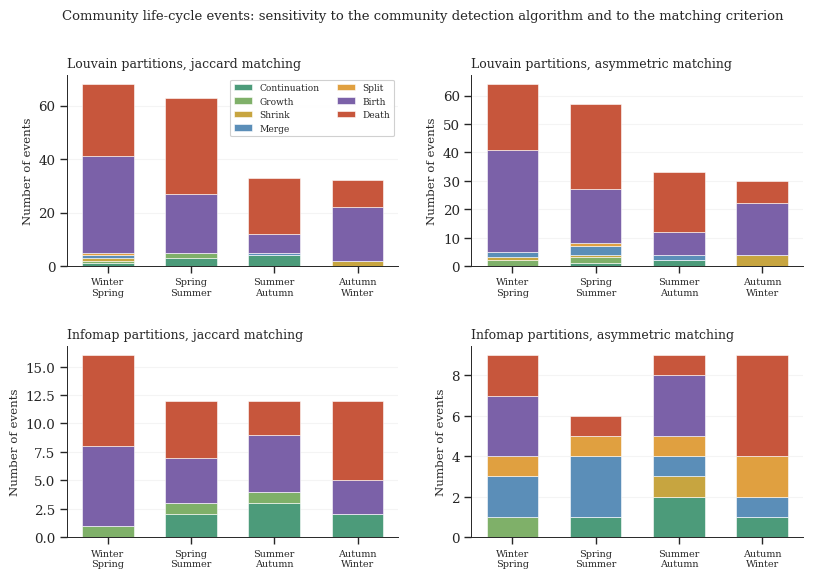

In [13]:
# ── Fig 1: eventi per transizione, quattro pannelli ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.0),
                         gridspec_kw={'wspace': 0.22, 'hspace': 0.42})

for ax, (algo, mname) in zip(axes.ravel(),
                             [(a, m) for a in ALGOS for m in MATCHERS]):
    key = (algo, mname)
    x = np.arange(len(TRANSITIONS))
    bottom = np.zeros(len(TRANSITIONS))
    for et in EVENT_TYPES:
        vals = np.array([event_counts[key][t].get(et, 0) for t in TRANSITIONS],
                        dtype=float)
        ax.bar(x, vals, bottom=bottom, label=et.capitalize(),
               color=EVENT_COLORS[et], edgecolor='white', width=0.62, linewidth=0.4)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels([f'{SEASON_NAMES[a][:6]}\n{SEASON_NAMES[b][:6]}'
                        for a, b in TRANSITIONS], fontsize=7)
    ax.set_ylabel('Number of events', fontsize=8.5)
    ax.set_title(f'{algo.capitalize()} partitions, {mname} matching',
                 fontsize=9, loc='left')
    ax.grid(axis='y', alpha=0.2)

axes[0, 0].legend(fontsize=6.5, frameon=True, framealpha=0.92,
                  edgecolor='#cccccc', ncol=2, loc='upper right')
fig.suptitle('Community life-cycle events: sensitivity to the community detection '
             'algorithm and to the matching criterion', fontsize=9.5, y=0.99)
sns.despine()
savefig(fig, 'dyn2_community_events')
plt.show()

  saved figures/dyn2_winter_cyclicity.png + .pdf


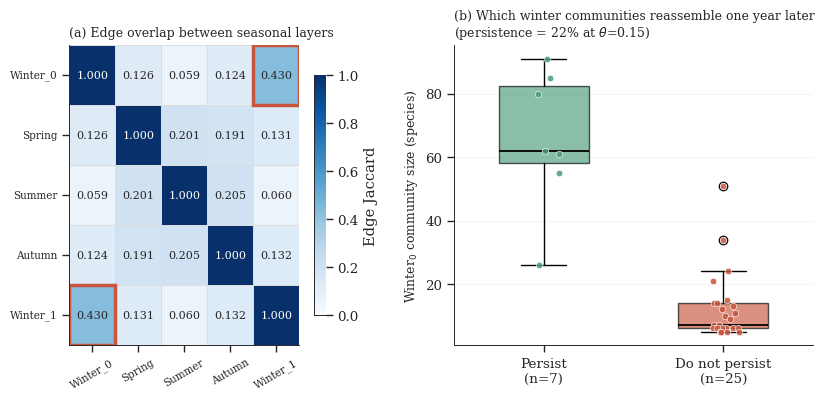

In [14]:
# ── Fig 2: edge Jaccard fra layer + ciclicita invernale ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.9),
                               gridspec_kw={'wspace': 0.30, 'width_ratios': [1, 1.25]})

# (a) matrice di overlap degli archi
sns.heatmap(df_edge_jac, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.6, linecolor='#dddddd', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8, 'label': 'Edge Jaccard'}, ax=ax1)
ax1.set_title('(a) Edge overlap between seasonal layers', fontsize=9, loc='left')
ax1.tick_params(axis='x', labelsize=7.5, rotation=30)
ax1.tick_params(axis='y', labelsize=7.5, rotation=0)
# Evidenzia la cella Winter_0 x Winter_1
iw0, iw1 = seas.index('winter_0'), seas.index('winter_1')
for (rr, cc) in [(iw0, iw1), (iw1, iw0)]:
    ax1.add_patch(plt.Rectangle((cc, rr), 1, 1, fill=False,
                                edgecolor='#C7563C', lw=2.5))

# (b) taglia delle comunita invernali, persistenti vs non persistenti
algo = 'louvain'
r = winter_results[algo]
data, labels, colors = [], [], []
if r['size_matched']:
    data.append(r['size_matched']);   labels.append(f'Persist\n(n={len(r["size_matched"])})')
    colors.append('#4C9B7A')
if r['size_unmatched']:
    data.append(r['size_unmatched']); labels.append(f'Do not persist\n(n={len(r["size_unmatched"])})')
    colors.append('#C7563C')
bp = ax2.boxplot(data, labels=labels, patch_artist=True, widths=0.5,
                 medianprops={'color': 'black', 'lw': 1.3})
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.65)
for i, d in enumerate(data):
    ax2.scatter(np.random.normal(i + 1, 0.05, len(d)), d, s=22,
                color=colors[i], alpha=0.85, zorder=3, edgecolors='white', linewidths=0.5)
ax2.set_ylabel('Winter$_0$ community size (species)', fontsize=9)
ax2.set_title(f'(b) Which winter communities reassemble one year later\n'
              f'(persistence = {r["persistence_jaccard"]:.0f}% at '
              rf'$\theta$={THETA_J})', fontsize=9, loc='left')
ax2.grid(axis='y', alpha=0.2)

sns.despine()
fig.tight_layout()
savefig(fig, 'dyn2_winter_cyclicity')
plt.show()

  saved figures/dyn2_species_flow_sankey.png + .pdf


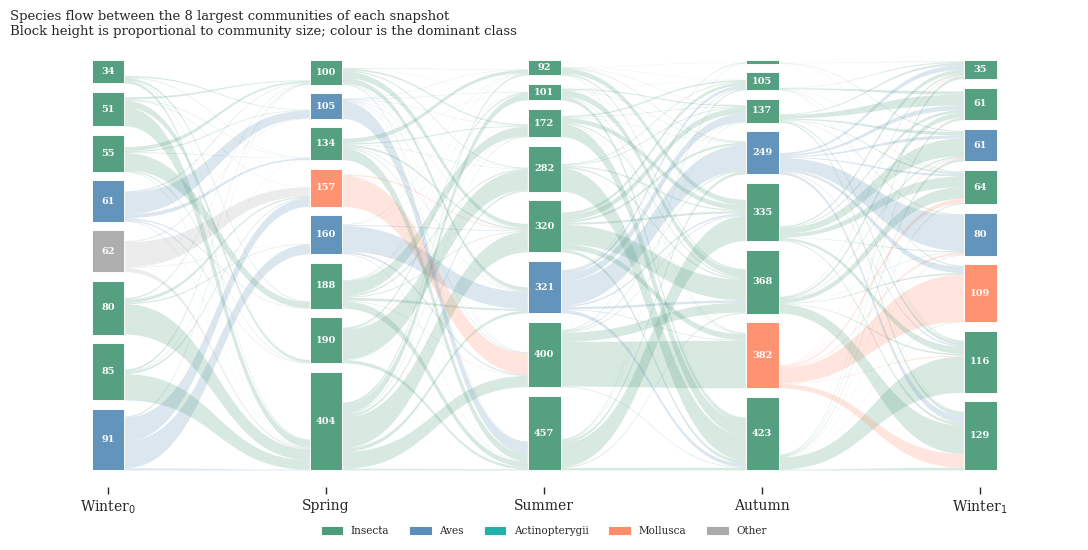

In [ ]:
# ─────────────
algo  = 'louvain'
TOP_N = 8

season_top = {s: dict(sorted(season_comms[algo][s].items(),
                             key=lambda kv: -len(kv[1]))[:TOP_N])
              for s in SEASONS}

fig, ax = plt.subplots(figsize=(11, 5.6))
col_x = {s: i for i, s in enumerate(SEASONS)}
GAP = 0.02

block_pos = {}
for s in SEASONS:
    comms = season_top[s]
    if not comms:
        continue
    total = sum(len(m) for m in comms.values())
    y = 0.0
    for cid, mem in sorted(comms.items(), key=lambda kv: -len(kv[1])):
        h = len(mem) / total * (1 - GAP * (len(comms) + 1))
        y += GAP
        block_pos[(s, cid)] = (y, y + h)
        y += h

def block_color(season, cid):
    mem = season_comms[algo][season].get(cid, set())
    if not mem:
        return '#AAAAAA'
    dom = Counter(taxon_iconic.get(t, 'Other') for t in mem).most_common(1)[0][0]
    return ICONIC_PAL.get(dom, '#AAAAAA')

def band(xa, ya0, ya1, xb, yb0, yb1, color, alpha=0.22):
    xm = (xa + xb) / 2
    verts = [(xa, ya1), (xm, ya1), (xm, yb1), (xb, yb1),
             (xb, yb0), (xm, yb0), (xm, ya0), (xa, ya0), (xa, ya1)]
    codes = ([Path.MOVETO] + [Path.CURVE4]*3 + [Path.LINETO] +
             [Path.CURVE4]*3 + [Path.CLOSEPOLY])
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, alpha=alpha,
                           edgecolor='none', zorder=1))

W = 0.15
for (s, cid), (y0, y1) in block_pos.items():
    ax.add_patch(mpatches.Rectangle((col_x[s] - W/2, y0), W, y1 - y0,
                 facecolor=block_color(s, cid), edgecolor='white',
                 linewidth=0.7, alpha=0.95, zorder=3))
    n = len(season_top[s][cid])
    if (y1 - y0) > 0.035:
        ax.text(col_x[s], (y0 + y1) / 2, str(n), ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=4)

for s1, s2 in TRANSITIONS:
    out_off = {c: 0.0 for c in season_top[s1]}
    in_off  = {c: 0.0 for c in season_top[s2]}
    for c1 in sorted(season_top[s1], key=lambda c: -len(season_top[s1][c])):
        for c2 in sorted(season_top[s2], key=lambda c: -len(season_top[s2][c])):
            shared = len(season_comms[algo][s1][c1] & season_comms[algo][s2][c2])
            if shared == 0:
                continue
            y0a, y1a = block_pos[(s1, c1)]
            y0b, y1b = block_pos[(s2, c2)]
            ha = (y1a - y0a) * shared / len(season_top[s1][c1])
            hb = (y1b - y0b) * shared / len(season_top[s2][c2])
            ya0 = y0a + out_off[c1]; out_off[c1] += ha
            yb0 = y0b + in_off[c2];  in_off[c2]  += hb
            band(col_x[s1] + W/2, ya0, ya0 + ha,
                 col_x[s2] - W/2, yb0, yb0 + hb, block_color(s1, c1))

ax.set_xlim(-0.45, len(SEASONS) - 0.55)
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(range(len(SEASONS)))
ax.set_xticklabels([SEASON_NAMES[s].replace('_', '$_') + '$'
                    if '_' in SEASON_NAMES[s] else SEASON_NAMES[s]
                    for s in SEASONS], fontsize=10)
ax.set_yticks([])
ax.set_title(f'Species flow between the {TOP_N} largest communities of each snapshot\n'
             'Block height is proportional to community size; colour is the dominant class',
             fontsize=9.5, loc='left')
handles = [mpatches.Patch(color=c, label=t) for t, c in ICONIC_PAL.items()
           if t in {'Insecta', 'Aves', 'Mollusca', 'Actinopterygii', 'Other'}]
ax.legend(handles=handles, fontsize=7.5, frameon=False, ncol=5,
          loc='lower center', bbox_to_anchor=(0.5, -0.13))
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
savefig(fig, 'dyn2_species_flow_sankey')
plt.show()